In [1]:
# Steps Done - 

# 1. Load the dataset that is given to you
# 2. Check for null values in the dataset
# 3. Print the percentage of default to a payer of the dataset for the TARGET column
# 4. Balance the dataset if the data is imbalanced
# 5. Plot the balanced or imbalanced data
# 6. Encode the columns that is required for the model
# 7. Calculate Sensitivity as a metric
# 8. Calculate the area under  the receiver operating characteristics curve



In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('loan_data.csv')
print(df)

        SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0           100002       1         Cash loans           M            N   
1           100003       0         Cash loans           F            N   
2           100004       0    Revolving loans           M            Y   
3           100006       0         Cash loans           F            N   
4           100007       0         Cash loans           M            N   
...            ...     ...                ...         ...          ...   
307506      456251       0         Cash loans           M            N   
307507      456252       0         Cash loans           F            N   
307508      456253       0         Cash loans           F            N   
307509      456254       1         Cash loans           F            N   
307510      456255       0         Cash loans           F            N   

       FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  \
0                    Y             0     

In [4]:
import pandas as pd

null_values = df.isnull().sum()

print(null_values[null_values > 0])


AMT_ANNUITY                       12
AMT_GOODS_PRICE                  278
NAME_TYPE_SUITE                 1292
OWN_CAR_AGE                   202929
OCCUPATION_TYPE                96391
                               ...  
AMT_REQ_CREDIT_BUREAU_DAY      41519
AMT_REQ_CREDIT_BUREAU_WEEK     41519
AMT_REQ_CREDIT_BUREAU_MON      41519
AMT_REQ_CREDIT_BUREAU_QRT      41519
AMT_REQ_CREDIT_BUREAU_YEAR     41519
Length: 67, dtype: int64


In [5]:
import pandas as pd

default_percentage = (df['TARGET'].sum() / len(df)) * 100

print(f"Percentage of defaults: {default_percentage:.2f}%")


Percentage of defaults: 8.07%


In [6]:
import pandas as pd

target_counts = df['TARGET'].value_counts()
print(target_counts)

imbalance_ratio = target_counts[1] / target_counts[0]
print("Imbalance ratio:", imbalance_ratio)


TARGET
0    282686
1     24825
Name: count, dtype: int64
Imbalance ratio: 0.08781828601345662


In [7]:
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
import pandas as pd


X = df.drop('TARGET', axis=1)

y = df['TARGET']

categorical_cols = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='mean'), X.select_dtypes(include=['number']).columns),
        ('cat', OneHotEncoder(), categorical_cols)
    ])

X_processed = preprocessor.fit_transform(X)


smote = SMOTE()
X_balanced, y_balanced = smote.fit_resample(X_processed, y)

feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)


all_feature_names = list(X.select_dtypes(include=['number']).columns) + list(feature_names)


df_balanced = pd.concat([pd.DataFrame(X_balanced, columns=all_feature_names), pd.Series(y_balanced, name='TARGET')], axis=1)


print(df_balanced['TARGET'].value_counts())



TARGET
1    282686
0    282686
Name: count, dtype: int64


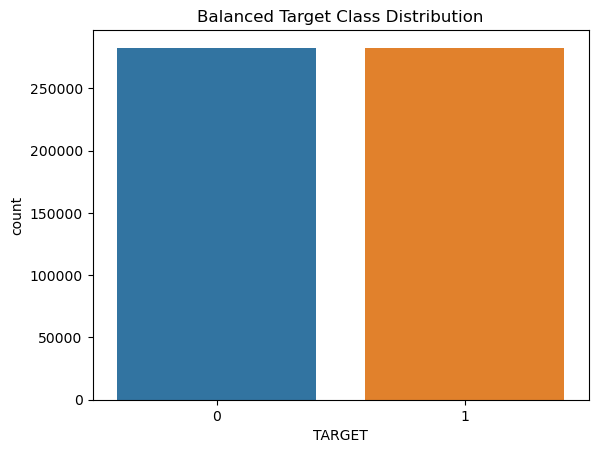

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='TARGET', data=df_balanced)
plt.title('Balanced Target Class Distribution')
plt.show()


In [9]:
import pandas as pd

categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical columns:", categorical_cols)


Categorical columns: Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import pandas as pd

X = df.drop('TARGET', axis=1)
y = df['TARGET']

categorical_cols = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']  # Update with your column names

remaining_cols = [col for col in X.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='mean'), remaining_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ])

X_processed = preprocessor.fit_transform(X)

feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)

all_feature_names = remaining_cols + list(feature_names)

X_encoded = pd.DataFrame(X_processed, columns=all_feature_names)

print(X_encoded.head())


   SK_ID_CURR  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0    100002.0           0.0          202500.0    406597.5      24700.5   
1    100003.0           0.0          270000.0   1293502.5      35698.5   
2    100004.0           0.0           67500.0    135000.0       6750.0   
3    100006.0           0.0          135000.0    312682.5      29686.5   
4    100007.0           0.0          121500.0    513000.0      21865.5   

   AMT_GOODS_PRICE  REGION_POPULATION_RELATIVE  DAYS_BIRTH  DAYS_EMPLOYED  \
0         351000.0                    0.018801     -9461.0         -637.0   
1        1129500.0                    0.003541    -16765.0        -1188.0   
2         135000.0                    0.010032    -19046.0         -225.0   
3         297000.0                    0.008019    -19005.0        -3039.0   
4         513000.0                    0.028663    -19932.0        -3038.0   

   DAYS_REGISTRATION  ...  WALLSMATERIAL_MODE_Mixed  \
0            -3648.0  ...            

In [5]:
import pandas as pd
import dask.dataframe as dd  # Assuming dask version compatible with pandas

# Read data in chunks using Dask DataFrame (adjust chunksize as needed)
df = dd.read_csv('loan_data.csv', chunksize=10000)

# Handle missing values (example with KNN imputation for numerical features)
from sklearn.impute import KNNImputer

numerical_cols = [col for col in df.columns if df[col].dtype != object]
categorical_cols = [col for col in df.columns if col not in numerical_cols]

imputer = KNNImputer(n_neighbors=5)  # Adjust parameters as needed
df[numerical_cols] = imputer.fit_transform(df[numerical_cols])

# Feature selection (replace with your selection method)
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(f_classif, k=20)  # Select top 20 features
selected_features = selector.fit_transform(df[numerical_cols + categorical_cols], df['TARGET'])

# Encoding categorical features (if necessary)
# This example uses one-hot encoding, replace with your preferred method
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse=False)  # Adjust sparse if needed
encoded_features = encoder.fit_transform(df[categorical_cols])

# Combine selected numerical and encoded categorical features
all_features = pd.concat([selected_features, encoded_features], axis=1)

# Split data into training and testing sets (replace with your split ratio)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(all_features, df['TARGET'], test_size=0.2)

# Machine Learning Model Training (replace with your chosen model)
from sklearn.ensemble import RandomForestClassifier  # Example model

model = RandomForestClassifier()
model.fit(X_train, y_train)

# Model Evaluation (replace with your desired metrics)
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ... (Further analysis or prediction using the trained model)


AttributeError: module 'pandas.core.strings' has no attribute 'StringMethods'

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense

X = df.drop('TARGET', axis=1)
y = df['TARGET']

categorical_cols = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']

remaining_cols = [col for col in X.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), remaining_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder())
        ]), categorical_cols)
    ])

X_processed = preprocessor.fit_transform(X)

feature_names = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(categorical_cols)

all_feature_names = remaining_cols + list(feature_names)

X_encoded = pd.DataFrame(X_processed, columns=all_feature_names)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Define the model
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_encoded.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Loss: {loss}, Accuracy: {accuracy}")


In [ ]:
y_true = y_test  
y_pred = model.predict(X_test) > 0.5  

cm = confusion_matrix(y_true, y_pred)

# Extract true positives and false negatives from the confusion matrix
tn, fp, fn, tp = cm.ravel()

# Calculate sensitivity
sensitivity = tp / (tp + fn)

print("Sensitivity:", sensitivity)
